#**CHAPTER 6.TRANSFORMERS**
---

##REFERENCE

https://chatgpt.com/share/69a71eca-ac3c-8012-bcab-f9be50fc1224

##0.CONTEXT

**Introduction**

Chapter 6 introduces the Transformer as a concrete answer to a specific mechanical problem that becomes increasingly visible as you move through the earlier chapters: once the signal in a sequence depends on *relationships between far-apart positions*, models that process tokens one step at a time begin to feel like they are carrying groceries with one hand tied behind their back. KNN gave us geometry. Dense networks gave us nonlinear mapping. CNNs gave us locality and weight sharing for spatial structure. RNNs and LSTMs gave us a sequential memory mechanism, but at the cost of processing positions strictly in order and compressing history into a single evolving state. The Transformer changes the rules by letting every position directly consult any earlier position through attention, turning “context” from a compressed summary into an explicit, learned weighting over prior tokens.

This notebook is deliberately synthetic and small, because the goal is not to build a useful language model. The goal is to make the Transformer’s mechanics visible. We want a dataset where the “right” prediction cannot always be made from the last token alone, and where the relevant clue may appear several steps earlier. To force that situation, the corpus is constructed from deterministic templates that embed dependencies across distance: structures like “if … then …” and subject–verb agreement patterns create conditions where earlier tokens (for example, a subject token or a connective such as “if” or “then”) legitimately matter when predicting later tokens. This is the most important design principle of the chapter: the data must *reward* context-sensitive behavior, otherwise attention becomes an expensive way of doing what a simpler model could already do.

A Transformer language model in its most minimal form can be described operationally as three staged mechanisms repeated across layers. First, tokens are converted into continuous vectors via an embedding table. Second, a positional encoding (here, a learned positional embedding) is added so the model can distinguish “this token at position 3” from “the same token at position 9.” Third, blocks of self-attention and feedforward transformations repeatedly mix and refine these vectors. The key novelty lies in self-attention: each position produces a distribution over earlier positions (because we use causal masking), and then forms a weighted combination of their vectors. This is not an abstract philosophical idea. It is a literal matrix multiplication that you can visualize: a square attention matrix where rows correspond to the “query” position (the position making a decision) and columns correspond to the “key” position (the position being consulted). The entries indicate how strongly each earlier token influences the representation used for prediction at each position.

The notebook emphasizes the training vs inference distinction in a way that is easy to overlook when people talk about Transformers as if they were magical “understanding engines.” Training is the repeated process of adjusting parameters so that, for many sequences, the model’s next-token predictions match the synthetic ground truth. Inference is what happens after training: you present a new synthetic sample that the model has not explicitly trained on, you run a forward pass, and you interpret its predicted tokens. The chapter’s objective is to make this distinction operational: you will see a loss curve during training, quantitative metrics on held-out test data during evaluation, and then a separate, clearly staged inference demonstration on a newly generated sample.

Visualization is not an optional decoration here. It is the instrument panel. You will visualize token frequencies to understand what the model is exposed to and where biases might arise from simple frequency effects. You will visualize sequences as heatmaps to develop an intuition for what “a batch of tokenized text” looks like as a tensor. Most importantly, you will visualize an attention matrix from the last layer so you can see what “context use” looks like in concrete numbers. Attention visualization is not perfect interpretability, but it is a uniquely direct window into the Transformer’s central operation: which past positions are being consulted when forming a prediction at each position.

Reproducible experimentation matters because Transformers can be unstable even at tiny scale if you allow randomness to dominate the story. For that reason, the notebook fixes seeds for Python, NumPy, and PyTorch, and it uses a small architecture with a strict cap on attention layers. This is not about performance; it is about visibility. You want a model small enough to train quickly and inspect easily, while still rich enough to learn nontrivial dependencies. The final result should be a notebook where the student can rerun the entire pipeline and see the same qualitative behavior: decreasing loss, nontrivial token accuracy, degradation under input corruption, and attention patterns that reflect a mixture of local continuity and occasional long-range jumps tied to the synthetic grammar.

Mechanically, the Transformer’s promise is simple: instead of pushing information through a narrow recurrent bottleneck, it allows the model to compute dependencies by direct weighted interaction among positions. That is the conceptual milestone of Chapter 6. The practical aim of the notebook is narrower: demonstrate that this mechanism can be trained end-to-end on a small synthetic corpus, quantify what it learns, show how it fails when context is disrupted, and visualize the attention matrix as the most explicit artifact of “contextual interaction” that the model produces.

By the end of this chapter, the student should be able to answer questions like: What exactly is an attention matrix in a causal language model? Why does the model need positional information even though it “sees” all tokens? How do causal masks enforce the training objective without leaking future information? What does it mean mechanically when attention concentrates near the diagonal versus when it jumps to far earlier tokens? And how does the distinction between training dynamics (loss decreasing by gradient descent) and inference behavior (a single forward pass producing predicted tokens) show up in a real, executable experiment?

This chapter also prepares the conceptual ground for the next stage of the sequence. Once you understand attention as a mechanism for learning distributions over structures, it becomes natural to ask how to learn *distributions of data* rather than just conditional next-token mappings. That transition motivates generative modeling chapters that follow, where the objective is not merely to predict the next token, but to generate samples from a learned distribution through different training paradigms. But for Chapter 6, the focus remains sharply on the Transformer’s mechanical core: attention as a learned, position-to-position routing rule that can be trained, measured, stressed, and visualized.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports, Determinism, Device, and Shared Plot/Training Utilities**

Cell 1 establishes the notebook’s “laboratory bench.” The most important point is that it makes later behavior interpretable by enforcing stable, repeatable conditions. The cell imports only the permitted libraries, then sets deterministic random seeds across Python’s `random`, NumPy, and PyTorch. This matters because even with a small Transformer, different initial weights and different shuffles can change early training trajectories. If you want to learn the mechanism, you must reduce noise in the experimental setup so that what you observe is caused by the architecture and the data rather than by randomness.

The cell also selects a device (GPU if available, otherwise CPU). This is not a performance obsession; it is a practical requirement for running end-to-end in Colab with predictable timing. More importantly, it forces all tensors and model parameters to live on the same device, preventing a common beginner failure mode where operations silently break due to mismatched devices.

Next, Cell 1 defines a unified plotting style and a required set of plotting utilities. Even though not all plots are used in this chapter, the notebook keeps a consistent interface across chapters. This lets students focus on what changes from chapter to chapter without also learning a new plotting API each time. The attention plot utility is especially important here: attention is a matrix, so the correct visualization is a heatmap with labeled axes. The plotting function forces this discipline by explicitly creating a figure, labeling axes, setting a title, and calling `plt.show()`.

Finally, the cell defines PyTorch helper functions for training, evaluation, and prediction. Mechanically, these are the core of “training vs inference distinction.” The `train_loop` function performs gradient-based parameter updates: it sets the model to training mode, shuffles data, runs forward passes, computes loss, backpropagates gradients, and steps the optimizer. It prints epoch progress and stores loss history so that training dynamics become a visible object rather than an abstract idea. The evaluation helper enforces `torch.no_grad()`, which is critical: during evaluation you want measurements, not parameter updates and not gradient tracking. The predict helper provides a clean forward-pass interface for inference demonstrations.

The student should internalize that these helpers are not “magic.” They are simply a standardized way to run the same set of operations repeatedly. In this chapter, those operations will be applied to token sequences. The model will output logits over a vocabulary at every position. The loss will compare those logits to the next-token targets. Everything else—the attention mechanism, the causal masking, the positional encoding—exists to make those logits better. Cell 1 sets up the experimental machinery so that when those improvements happen, you can see them and measure them.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import time
import random
from typing import Dict, Tuple, List, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Determinism (required)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Plotting utilities (required)
# -------------------------------
def plot_loss_curve(losses, title="Training Loss Curve"):
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)
    ax.plot(np.arange(len(losses)), losses)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.show()

def plot_2d_data(X, y, title="2D Data"):
    X = np.asarray(X)
    y = np.asarray(y)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Generic placeholder for non-2D classifiers; included to satisfy shared API.
    X = np.asarray(X)
    y = np.asarray(y)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20)
    ax.set_title(title + " (not applicable in this chapter)")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.show()

def show_image(img, title="Image"):
    img = np.asarray(img)
    fig = plt.figure(figsize=(7, 2))
    ax = fig.add_subplot(111)
    ax.imshow(img, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Index")
    ax.set_ylabel("Row")
    plt.show()

def show_image_grid(images, labels=None, title="Image Grid"):
    images = np.asarray(images)
    n = images.shape[0]
    cols = min(6, n)
    rows = int(math.ceil(n / cols))
    fig = plt.figure(figsize=(cols * 2.0, rows * 2.0))
    for i in range(n):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(images[i], aspect="auto")
        if labels is not None:
            ax.set_title(str(labels[i]))
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    plt.show()

def plot_histograms(real, fake, title="Histogram"):
    real = np.asarray(real).reshape(-1)
    fake = np.asarray(fake).reshape(-1)
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)
    ax.hist(real, bins=30, alpha=0.6, label="Real")
    ax.hist(fake, bins=30, alpha=0.6, label="Fake")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()
    plt.show()

def plot_attention(matrix, title="Attention Matrix"):
    matrix = np.asarray(matrix)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    im = ax.imshow(matrix, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

def plot_graph(G, node_values=None, title="Graph"):
    # Placeholder for non-graph chapters; included to satisfy shared API.
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    ax.set_title(title + " (not applicable in this chapter)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.show()

# -------------------------------
# PyTorch helpers (required)
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=10, batch_size=64):
    model.train()
    losses = []
    N = X.shape[0]
    for epoch in range(1, epochs + 1):
        perm = torch.randperm(N, device=X.device)
        epoch_loss = 0.0
        steps = 0
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            xb = X[idx]
            yb = y[idx]
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)  # [B, T, V]
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), yb.reshape(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += float(loss.detach().cpu().item())
            steps += 1
        avg = epoch_loss / max(1, steps)
        losses.append(avg)
        print(f"Epoch {epoch:03d}/{epochs:03d} | loss={avg:.6f}")
    return losses

@torch.no_grad()
def evaluate(model, loss_fn, X, y, batch_size=128):
    model.eval()
    N = X.shape[0]
    total_loss = 0.0
    total_tok = 0
    correct = 0
    for i in range(0, N, batch_size):
        xb = X[i:i + batch_size]
        yb = y[i:i + batch_size]
        logits = model(xb)  # [B, T, V]
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), yb.reshape(-1))
        total_loss += float(loss.detach().cpu().item()) * xb.shape[0]
        preds = torch.argmax(logits, dim=-1)  # [B, T]
        correct += int((preds == yb).sum().detach().cpu().item())
        total_tok += int(yb.numel())
    avg_loss = total_loss / max(1, N)
    acc = correct / max(1, total_tok)
    return {"avg_loss": avg_loss, "token_accuracy": acc, "total_tokens": total_tok}

@torch.no_grad()
def predict(model, X):
    model.eval()
    logits = model(X)
    preds = torch.argmax(logits, dim=-1)
    return logits, preds

##2.DATA GENERATORS

###2.1.OVERVIEW


**Cell 2 — Synthetic Text Corpus, Vocabulary, Encoding, and Train/Test Split Generators**

Cell 2 defines the synthetic data machinery. This chapter’s dataset must be designed to reward context use. If the data were purely local—if each token depended only on the previous token—then the Transformer’s attention mechanism would have little reason to develop meaningful long-range patterns. The corpus generator therefore uses deterministic templates that embed compositional structure, including patterns like subject–verb agreement (singular/plural) and clause structures (“if … then …”). These templates create situations where earlier tokens constrain later ones, even if several tokens intervene.

The generator uses NumPy-only randomness, which is important for two reasons. First, it satisfies the notebook constraints: data generation must be deterministic and independent of high-level libraries. Second, it isolates the randomness to a single, controllable source, so you can reliably reproduce the same corpus given the same seed and parameters.

After generating token lists, the cell builds a vocabulary mapping tokens to integer ids. The mapping is made deterministic by sorting tokens lexicographically and optionally including special tokens such as `<pad>`, `<bos>`, `<eos>`, and `<unk>`. Those special tokens are not decorative. They are the mechanical infrastructure needed to represent variable-length sequences in fixed-length tensors. `<bos>` and `<eos>` give the model explicit boundary markers, which helps stabilize training for sequence prediction. `<pad>` allows shorter sequences to be aligned in fixed windows without introducing accidental token ids that look like real words.

The encoding function then constructs the actual supervised learning problem: next-token prediction. It creates a fixed-length window of token ids and a shifted target window. The input tensor `X` contains token ids at positions 0 through T−1, while the target `y` contains the “next” token ids at positions 1 through T. This is the fundamental training objective of a causal language model. Everything in the Transformer will ultimately be evaluated by how well it predicts `y` from `X`.

Finally, the cell defines a deterministic train/test split using a seeded permutation. This is crucial because evaluation metrics must reflect generalization, not memorization of the exact training sequences. Even with synthetic templates, a held-out test set ensures you measure whether the model learned the underlying structure rather than simply overfitting to the specific sampled sentences.

The main assumption embedded in this cell is that the synthetic grammar is simple enough for a tiny Transformer to learn, but rich enough to require some form of contextual interaction. That balance is the design art of the notebook: you want complexity that reveals mechanisms, not complexity that hides them behind training failure.



###2.2.CODE AND IMPLEMENTATION

In [3]:
# ===============================
# CELL 2
# ===============================
# Synthetic text corpus generators (numpy-only, deterministic, parameterized)

def generate_text_corpus(
    n_sentences: int = 6000,
    max_len: int = 14,
    vocab_seed: int = 0,
) -> List[List[str]]:
    """
    Generates a simple compositional corpus with predictable structure:
    - Sentences are built from templates with subjects/verbs/objects/modifiers.
    - The goal is to create strong long-range dependencies (subject -> verb agreement)
      and compositional regularities (modifier patterns), suitable for attention.

    Returns: list of token lists (no numpy arrays yet; tokens are strings).
    """
    rng = np.random.default_rng(vocab_seed)

    # Small controlled lexicon
    subjects_singular = np.array(["cat", "dog", "trader", "analyst", "robot"])
    subjects_plural = np.array(["cats", "dogs", "traders", "analysts", "robots"])

    verbs_singular = np.array(["runs", "jumps", "trades", "prices", "learns"])
    verbs_plural = np.array(["run", "jump", "trade", "price", "learn"])

    objects = np.array(["alpha", "risk", "market", "signal", "portfolio"])
    adjs = np.array(["small", "fast", "noisy", "stable", "weird"])
    advs = np.array(["today", "quickly", "slowly", "often", "rarely"])

    # Template choices
    # Template A: "the {adj} {subj} {verb} {obj} {adv} ."
    # Template B: "{subj} and {subj2} {verb_pl} {obj} ."
    # Template C: "if {subj} {verb} {obj} then {subj2} {verb2} {obj2} ."
    corpus = []
    for _ in range(n_sentences):
        t = int(rng.integers(0, 3))
        if t == 0:
            is_plural = bool(rng.integers(0, 2))
            subj = subjects_plural[int(rng.integers(0, len(subjects_plural)))] if is_plural else subjects_singular[int(rng.integers(0, len(subjects_singular)))]
            verb = verbs_plural[int(rng.integers(0, len(verbs_plural)))] if is_plural else verbs_singular[int(rng.integers(0, len(verbs_singular)))]
            sent = ["the", str(adjs[int(rng.integers(0, len(adjs)))]), str(subj), str(verb), str(objects[int(rng.integers(0, len(objects)))]), str(advs[int(rng.integers(0, len(advs)))]), "."]
        elif t == 1:
            subj1 = subjects_plural[int(rng.integers(0, len(subjects_plural)))]
            subj2 = subjects_plural[int(rng.integers(0, len(subjects_plural)))]
            verb = verbs_plural[int(rng.integers(0, len(verbs_plural)))]
            sent = [str(subj1), "and", str(subj2), str(verb), str(objects[int(rng.integers(0, len(objects)))]), "."]
        else:
            # Force longer dependency: "if X ... then Y ..."
            is_plural1 = bool(rng.integers(0, 2))
            is_plural2 = bool(rng.integers(0, 2))
            subj1 = subjects_plural[int(rng.integers(0, len(subjects_plural)))] if is_plural1 else subjects_singular[int(rng.integers(0, len(subjects_singular)))]
            subj2 = subjects_plural[int(rng.integers(0, len(subjects_plural)))] if is_plural2 else subjects_singular[int(rng.integers(0, len(subjects_singular)))]
            verb1 = verbs_plural[int(rng.integers(0, len(verbs_plural)))] if is_plural1 else verbs_singular[int(rng.integers(0, len(verbs_singular)))]
            verb2 = verbs_plural[int(rng.integers(0, len(verbs_plural)))] if is_plural2 else verbs_singular[int(rng.integers(0, len(verbs_singular)))]
            obj1 = objects[int(rng.integers(0, len(objects)))]
            obj2 = objects[int(rng.integers(0, len(objects)))]
            sent = ["if", str(subj1), str(verb1), str(obj1), "then", str(subj2), str(verb2), str(obj2), "."]
        # Enforce max_len via truncation (keeps determinism)
        sent = sent[:max_len]
        corpus.append(sent)
    return corpus

def build_vocab(corpus: List[List[str]], add_special: bool = True) -> Dict[str, int]:
    """
    Build vocabulary mapping from tokens to integer ids.
    Deterministic: tokens are sorted lexicographically.
    """
    tokens = set()
    for sent in corpus:
        for tok in sent:
            tokens.add(tok)
    base = sorted(list(tokens))
    vocab = {}
    idx = 0
    if add_special:
        for t in ["<pad>", "<bos>", "<eos>", "<unk>"]:
            vocab[t] = idx
            idx += 1
    for t in base:
        if t not in vocab:
            vocab[t] = idx
            idx += 1
    return vocab

def encode_corpus(
    corpus: List[List[str]],
    vocab: Dict[str, int],
    seq_len: int = 12,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Encode corpus into fixed-length token id sequences suitable for next-token prediction.

    We create:
      X: [N, seq_len]  tokens (input)
      y: [N, seq_len]  next tokens (targets)

    Construction:
      ids = [<bos>] + sentence + [<eos>]
      take a window of length seq_len+1 from ids (pad if short),
      then X is first seq_len, y is next seq_len.

    All operations are numpy-only and deterministic.
    """
    pad_id = vocab["<pad>"]
    bos_id = vocab["<bos>"]
    eos_id = vocab["<eos>"]
    unk_id = vocab["<unk>"]

    X_list = []
    y_list = []

    for sent in corpus:
        ids = [bos_id]
        for tok in sent:
            ids.append(vocab.get(tok, unk_id))
        ids.append(eos_id)

        # Build a single window deterministically from the start
        need = seq_len + 1
        if len(ids) < need:
            ids = ids + [pad_id] * (need - len(ids))
        else:
            ids = ids[:need]

        x = np.array(ids[:-1], dtype=np.int64)
        y = np.array(ids[1:], dtype=np.int64)
        X_list.append(x)
        y_list.append(y)

    X = np.stack(X_list, axis=0)
    y = np.stack(y_list, axis=0)
    return X, y

def train_test_split_numpy(X: np.ndarray, y: np.ndarray, test_ratio: float = 0.2, seed: int = 0):
    rng = np.random.default_rng(seed)
    N = X.shape[0]
    perm = rng.permutation(N)
    n_test = int(round(N * test_ratio))
    test_idx = perm[:n_test]
    train_idx = perm[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

##3.DATA CREATION

###3.1.OVERVIEW

**Cell 3 — Dataset Construction, Tensor Preparation, and Clean Visualization**

Cell 3 instantiates the data generators from Cell 2, producing a concrete dataset. This is where abstract ideas become objects with shapes: arrays with dimensions, vocabularies with sizes, and tensors placed on a device. The cell creates the corpus, builds the vocabulary, encodes sequences into fixed-length windows, and splits into train and test sets. Then it converts the NumPy arrays into PyTorch tensors with correct dtypes (`long` for token ids) and consistent device placement. This is not a trivial detail: embedding layers require integer indices, so using float tensors for token ids would be mechanically incorrect.

The visualization in this cell serves two purposes. First, token frequency plots reveal what the model sees most often. In synthetic corpora, special tokens and punctuation can dominate frequency counts, which can bias predictions and inflate certain metrics. Seeing the distribution helps you interpret later behavior: if `<pad>` or “.” appears extremely often, you should expect the model to become very confident about these tokens in certain positions.

Second, sequence visualization as a heatmap shows what tokenized data looks like in the raw tensor form the model consumes. Instead of printing long strings into a figure title (which becomes unreadable), the clean approach is to show a matrix image where each row is a sequence and each column is a position. This makes padding patterns and structural regularities visible. For example, if many sequences are shorter than the fixed window, you will see bands of identical ids corresponding to `<pad>`. If templates have common prefixes such as `<bos> if ...`, you will see repeated patterns in early columns.

The cell also prints decoded sample sequences line-by-line. This is a key pedagogical move: the heatmap is useful for seeing structure at a glance, but the student still needs to connect numeric ids back to tokens. Printing a handful of decoded sequences provides that grounding without destroying the readability of the plots.

The main “student observation” goal here is to connect three representations of the same object: the human-readable token sequence, the integer-id vector, and the 2D batch tensor. The Transformer never sees words. It sees integer ids, which become embeddings, which become context-mixed representations. If that representational pipeline feels real at this stage, the later attention matrix becomes much easier to interpret because you can mentally map matrix rows and columns back to token positions and token identities.

###3.2.CODE AND IMPLEMENTATION

Device: cpu
Vocab size: 44
Train sequences: torch.Size([4800, 12]) Test sequences: torch.Size([1200, 12])


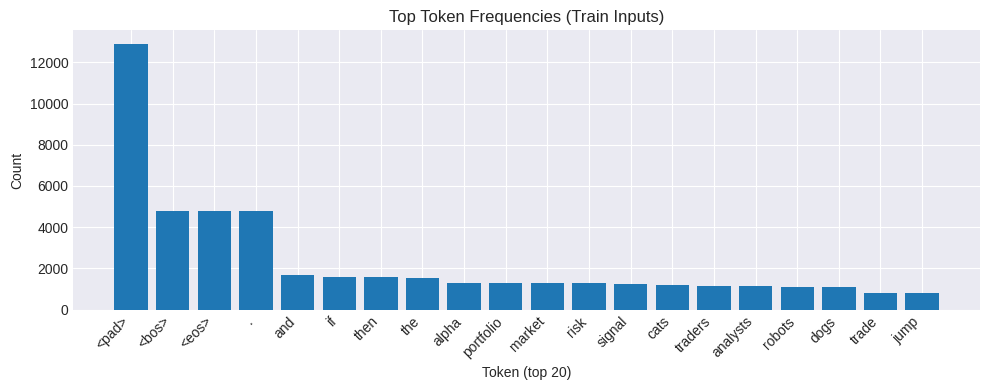

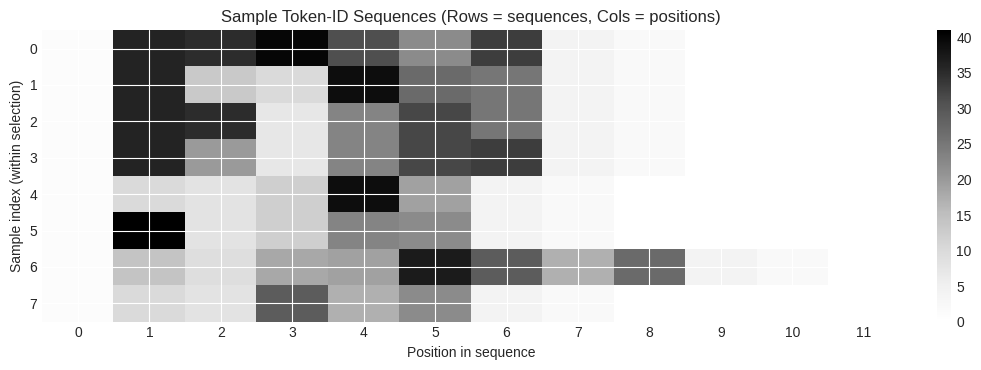


Decoded sample sequences:
[00] <bos> the stable trader runs portfolio slowly . <eos> <pad> <pad> <pad>
[01] <bos> the fast cats trade risk quickly . <eos> <pad> <pad> <pad>
[02] <bos> the stable analysts price signal quickly . <eos> <pad> <pad> <pad>
[03] <bos> the noisy analysts price signal slowly . <eos> <pad> <pad> <pad>
[04] <bos> cats and dogs trade market . <eos> <pad> <pad> <pad> <pad>
[05] <bos> traders and dogs price portfolio . <eos> <pad> <pad> <pad> <pad>
[06] <bos> if cat learns market then robots learn risk . <eos> <pad>
[07] <bos> cats and robots learn portfolio . <eos> <pad> <pad> <pad> <pad>


In [17]:
# ===============================
# CELL 3
# ===============================
# Dataset creation + visualization (cleaner, no long per-tile titles)

SEQ_LEN = 12
N_SENTENCES = 6000

corpus = generate_text_corpus(n_sentences=N_SENTENCES, max_len=14, vocab_seed=0)
vocab = build_vocab(corpus, add_special=True)

X_np, y_np = encode_corpus(corpus, vocab=vocab, seq_len=SEQ_LEN)
X_train_np, y_train_np, X_test_np, y_test_np = train_test_split_numpy(X_np, y_np, test_ratio=0.2, seed=0)

# Tensors
X_train = torch.tensor(X_train_np, dtype=torch.long, device=DEVICE)
y_train = torch.tensor(y_train_np, dtype=torch.long, device=DEVICE)
X_test = torch.tensor(X_test_np, dtype=torch.long, device=DEVICE)
y_test = torch.tensor(y_test_np, dtype=torch.long, device=DEVICE)

id_to_tok = {i: t for t, i in vocab.items()}

print("Device:", DEVICE)
print("Vocab size:", len(vocab))
print("Train sequences:", X_train.shape, "Test sequences:", X_test.shape)

# -------------------------------
# Visualization A: token frequency (top 20) with readable labels
# -------------------------------
counts = np.zeros(len(vocab), dtype=np.int64)
flat = X_train_np.reshape(-1)
for i in range(flat.shape[0]):
    counts[int(flat[i])] += 1

topk = 20
top_ids = np.argsort(-counts)[:topk]
top_labels = [id_to_tok[int(i)] for i in top_ids]
top_vals = counts[top_ids]

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)
ax.bar(np.arange(topk), top_vals)
ax.set_title("Top Token Frequencies (Train Inputs)")
ax.set_xlabel("Token (top 20)")
ax.set_ylabel("Count")
ax.set_xticks(np.arange(topk))
ax.set_xticklabels(top_labels, rotation=45, ha="right")
fig.tight_layout()
plt.show()

# -------------------------------
# Visualization B: show multiple sequences as a single heatmap (no messy titles)
# -------------------------------
sample_n = 8
rng = np.random.default_rng(0)
sample_idx = rng.choice(X_train_np.shape[0], size=sample_n, replace=False)

seq_matrix = X_train_np[sample_idx, :].astype(np.float32)  # [N, T]

fig = plt.figure(figsize=(10, 3.8))
ax = fig.add_subplot(111)
im = ax.imshow(seq_matrix, aspect="auto")
ax.set_title("Sample Token-ID Sequences (Rows = sequences, Cols = positions)")
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Sample index (within selection)")
ax.set_xticks(np.arange(SEQ_LEN))
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

# Print decoded sequences cleanly (one per line) instead of cramming them into plot titles
print("\nDecoded sample sequences:")
for r, idx in enumerate(sample_idx.tolist()):
    toks = [id_to_tok[int(t)] for t in X_train_np[idx]]
    print(f"[{r:02d}] " + " ".join(toks))

##4.MODEL DEFINITION

###4.1.OVERVIEW

**Cell 4 — Tiny Causal Transformer Language Model Definition**

Cell 4 defines the model architecture. The design is intentionally minimal and constrained: a small embedding dimension, a small number of attention heads, and at most two Transformer blocks. This matches the chapter’s requirement and keeps the model’s behavior inspectable. The purpose is not state-of-the-art performance; it is to expose the mechanics of attention, positional encoding, and causal masking in a model that trains quickly and produces stable artifacts.

The model is a causal language model. Mechanically, this means that at position t, the model is allowed to use tokens from positions ≤ t but not from positions > t. This constraint is implemented through a causal attention mask: an upper-triangular matrix with negative infinity values above the diagonal. When passed into multi-head attention, this mask forces attention weights to be zero for “future” positions. This is essential. Without the mask, the model could cheat during training by attending to the very token it is supposed to predict. The causal mask enforces the training objective so that learning requires forming useful representations of past context.

The architecture has three core components. First, token embeddings map each integer id to a continuous vector. Second, positional embeddings add a learned vector that depends on sequence position. This step is crucial because attention alone is permutation-invariant: if you removed positional information, the model would not know whether a token occurred early or late, which breaks the meaning of sequential structure. Third, the Transformer blocks repeatedly apply layer normalization, self-attention, residual connections, and a feedforward network. The residual connections matter because they stabilize optimization by allowing information to flow around the nonlinear transformations. The feedforward network provides local nonlinear mixing at each position after attention has already mixed information across positions.

A notable feature of this notebook’s implementation is that it stores the last-layer attention weights. This is what enables interpretability in Cell 9. Without capturing attention weights, “attention” would remain an internal operation that you could only infer indirectly from performance. By explicitly exposing the attention matrix, the notebook turns attention into an inspectable artifact.

The student should understand that the model outputs logits of shape [B, T, V], meaning that for every batch element and every position, the model produces a score for every vocabulary token. Training will push these logits so that the correct next token has high score. Attention and positional embeddings exist to make those logits depend on the right contextual information. Cell 4 is where that dependency structure is engineered into the model.

###4.2.CODE AND IMPLEMENTATION

In [18]:
# ===============================
# CELL 4
# ===============================
# Model definition (Tiny Transformer with attention weights exposed)

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True)
        self.last_attn = None  # will store [B, H, T, T] or [B, T, T] depending on PyTorch version

    def forward(self, x, attn_mask):
        # need_weights=True to retrieve attention; average_attn_weights=False to keep head dimension when supported
        out, attn = self.mha(x, x, x, attn_mask=attn_mask, need_weights=True, average_attn_weights=False)
        self.last_attn = attn
        return out

class TinyTransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attn_mask):
        x_norm = self.ln1(x)
        a = self.attn(x_norm, attn_mask=attn_mask)
        x = x + self.dropout(a)
        x_norm = self.ln2(x)
        f = self.ff(x_norm)
        x = x + self.dropout(f)
        return x

class TinyCausalTransformerLM(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, d_model: int = 64, n_heads: int = 4, n_layers: int = 2, d_ff: int = 128, dropout: float = 0.0):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.d_model = d_model

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)

        self.blocks = nn.ModuleList([
            TinyTransformerBlock(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

        # Precompute causal mask (T x T) with -inf above diagonal
        # MultiheadAttention expects float mask with -inf for disallowed positions.
        mask = torch.full((seq_len, seq_len), float("-inf"))
        mask = torch.triu(mask, diagonal=1)  # upper triangle above diagonal
        self.register_buffer("causal_mask", mask, persistent=False)

    def forward(self, token_ids: torch.Tensor):
        # token_ids: [B, T], T must equal seq_len for this pedagogical notebook
        B, T = token_ids.shape
        assert T == self.seq_len, f"Expected T={self.seq_len}, got {T}"

        tok = self.tok_emb(token_ids)  # [B, T, D]
        pos_ids = torch.arange(T, device=token_ids.device, dtype=torch.long).unsqueeze(0).expand(B, T)
        pos = self.pos_emb(pos_ids)    # [B, T, D]
        x = tok + pos

        attn_mask = self.causal_mask  # [T, T]
        for blk in self.blocks:
            x = blk(x, attn_mask=attn_mask)

        x = self.ln_f(x)
        logits = self.head(x)  # [B, T, V]
        return logits

    def get_last_attention(self):
        # Return attention from the last block (if available)
        return self.blocks[-1].attn.last_attn

VOCAB_SIZE = len(vocab)
model = TinyCausalTransformerLM(
    vocab_size=VOCAB_SIZE,
    seq_len=SEQ_LEN,
    d_model=64,
    n_heads=4,
    n_layers=2,   # <= 2 attention layers (required)
    d_ff=128,
    dropout=0.0
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print("Model parameters:", n_params)

Model parameters: 73516


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 5 — Training the Transformer on Next-Token Prediction**

Cell 5 performs training. Mechanically, training here means optimizing parameters to minimize cross-entropy loss between predicted logits and the true next-token targets. Cross-entropy is stable and appropriate because the targets are discrete token ids. The cell defines an optimizer (Adam) and runs the shared `train_loop`. The loop shuffles training sequences each epoch, batches them, runs a forward pass to produce logits, computes loss, backpropagates gradients, and updates parameters.

The most important conceptual point is what the loss is actually measuring. Because the model predicts a distribution over vocabulary tokens at each position, the loss penalizes the model whenever it assigns low probability to the true next token. Over time, the optimizer adjusts embeddings, attention projections, and feedforward layers so that the model becomes better at mapping a prefix of tokens to the next token at every position in the sequence window.

The loss curve is not just a diagnostic; it is the training dynamics made visible. Early epochs typically show rapid loss reduction as the model learns easy statistics: frequent tokens, punctuation placement, and common template fragments. Later epochs may show slower improvement as the model refines longer-range dependencies, such as agreement and conditional clause structure. If the loss does not decrease, it is usually a sign of a mechanical issue (wrong shapes, wrong masking, wrong dtype) or a mismatch between model capacity and dataset complexity.

This cell also enforces the training vs inference distinction by implication. During training, the model is in “train mode,” meaning dropout (if used) would be active and gradient tracking is enabled. The purpose is parameter change. In later cells, evaluation and inference will run in no-grad mode, where the purpose is measurement and demonstration.

The student should watch the epoch-by-epoch printed losses and form an intuition about what “learning” looks like in a Transformer. It is not a mystical event. It is a measurable reduction in average cross-entropy achieved by thousands of small parameter updates. That is the mechanical foundation of everything else you will interpret later.

###5.2.CODE AND IMPLEMENTATION

In [6]:
# ===============================
# CELL 5
# ===============================
# Training loop (store loss history)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

EPOCHS = 18
BATCH_SIZE = 128

losses = train_loop(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    X=X_train,
    y=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 001/018 | loss=1.723233
Epoch 002/018 | loss=0.875562
Epoch 003/018 | loss=0.834526
Epoch 004/018 | loss=0.829665
Epoch 005/018 | loss=0.827633
Epoch 006/018 | loss=0.823929
Epoch 007/018 | loss=0.823112
Epoch 008/018 | loss=0.821702
Epoch 009/018 | loss=0.821549
Epoch 010/018 | loss=0.820331
Epoch 011/018 | loss=0.821149
Epoch 012/018 | loss=0.819085
Epoch 013/018 | loss=0.819449
Epoch 014/018 | loss=0.818386
Epoch 015/018 | loss=0.818183
Epoch 016/018 | loss=0.816904
Epoch 017/018 | loss=0.817666
Epoch 018/018 | loss=0.817062





##6.EVALUATION

###6.1.OVERVIEW

**Cell 6 — Evaluation Metrics and Loss Curve Visualization**

Cell 6 evaluates the trained model on both the training set and a held-out test set. This is where the notebook turns training success into quantitative statements. Evaluation computes average loss and token-level accuracy. Token accuracy here is a simple metric: at each position, the model’s argmax prediction is compared to the true next token. This is a strict measure—language modeling is probabilistic, and there may be multiple plausible tokens—but for synthetic templates, it becomes meaningful because the grammar is constrained.

The cell enforces best practice by using `torch.no_grad()` during evaluation. Mechanically, this prevents PyTorch from storing computation graphs and gradients, reducing memory usage and ensuring that evaluation cannot accidentally alter model state through gradient operations. The model is also set to evaluation mode internally, which would disable dropout if it were present.

The loss curve plot is the visual companion to the printed losses from training. It provides a quick global view of training dynamics: smooth decrease, plateaus, or instability. In a well-behaved run, you expect a broadly decreasing curve. Small fluctuations can happen due to minibatch sampling, but major oscillations or increases are usually a sign that the learning rate is too high or that the model is struggling to fit the task.

This cell also clarifies generalization. If the training metrics are dramatically better than the test metrics, it suggests overfitting: the model learned details of the specific training sequences rather than the underlying template rules. If the metrics are similar, it suggests the model captured the structure that generalizes across sampled sentences.

The student should interpret these numbers as the outcome of a specific supervised objective: next-token prediction under causal masking. Accuracy is not “understanding.” It is the fraction of positions where the model’s top prediction matches the synthetic target. The value of the metric is that it is grounded: it tells you exactly how often the model is correct in this specific task, and it provides the baseline for later stress tests.

###6.2.CODE AND IMPLEMENTATION

Train metrics: {'avg_loss': 0.8124175930023193, 'token_accuracy': 0.6433506944444445, 'total_tokens': 57600}
Test metrics: {'avg_loss': 0.8310282985369365, 'token_accuracy': 0.6240277777777777, 'total_tokens': 14400}


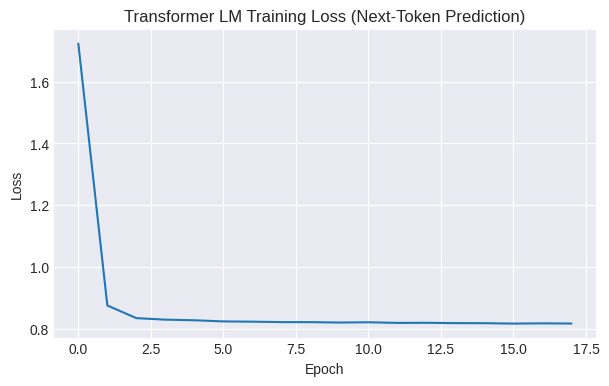

In [7]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot loss curve

train_metrics = evaluate(model, loss_fn, X_train, y_train, batch_size=256)
test_metrics = evaluate(model, loss_fn, X_test, y_test, batch_size=256)

print("Train metrics:", train_metrics)
print("Test metrics:", test_metrics)

plot_loss_curve(losses, title="Transformer LM Training Loss (Next-Token Prediction)")

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference Demonstration on a New Synthetic Sample**

Cell 7 is the notebook’s explicit inference demonstration. The key requirement is that it uses a newly generated synthetic sample that is not simply pulled from the training set. This matters because inference is about how a trained model behaves on fresh inputs. The cell generates a new sentence deterministically using a different seed, encodes it into the fixed window format, and runs a forward pass through the trained model to produce predicted next tokens.

The cell then prints three aligned objects: the input token ids (what the model sees), the target next-token ids (the ground truth defined by the encoding), and the predicted next-token ids (the model’s argmax output). It also decodes these sequences back into tokens so the student can compare the predicted continuation token-by-token. This is crucial: numeric ids are not interpretable without mapping back to tokens, and the educational value of the chapter depends on connecting model output to human-readable sequences.

The cell also visualizes the input as a heatmap, reinforcing that inference is just a forward computation over tensors. The Transformer takes integer ids, looks up embeddings, adds positional information, computes attention-weighted mixtures, and outputs logits. The prediction is then an argmax over the vocabulary dimension. There is no optimization in this step. No gradients. No parameter updates. Just computation.

What should the student observe? First, the model often gets easy structural tokens correct: punctuation, padding, and frequent template words. Second, the model’s performance on more contentful tokens reveals whether it learned the template rules. For example, subject–verb agreement patterns provide a test: if the model sees a plural subject earlier, does it prefer the plural verb form later? Similarly, conditional templates can create positions where tokens like “then” strongly constrain what comes next.

This cell is the cleanest “before and after” demonstration of training. Before training, predictions would be effectively random or dominated by frequency. After training, predictions reflect learned structure. That contrast is the conceptual payoff of the chapter’s training pipeline.

###7.2.CODE AND IMPLEMENTATION

New sentence tokens: ['the', 'weird', 'traders', 'run', 'risk', 'quickly', '.']
Input ids: [1, 36, 43, 41, 30, 27, 25, 4, 2, 0, 0, 0]
Target (next-token) ids: [36, 43, 41, 30, 27, 25, 4, 2, 0, 0, 0, 0]
Predicted next-token ids: [36, 43, 11, 15, 32, 38, 4, 2, 0, 0, 0, 0]

Decoded input:
<bos> the weird traders run risk quickly . <eos> <pad> <pad> <pad>

Decoded target (next tokens):
the weird traders run risk quickly . <eos> <pad> <pad> <pad> <pad>

Decoded prediction (argmax next tokens):
the weird dog jump signal today . <eos> <pad> <pad> <pad> <pad>


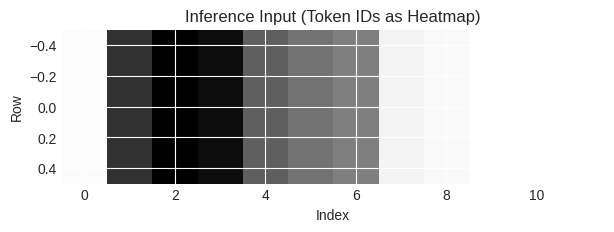

In [8]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration: new synthetic sample + prediction + visual display + printed output

def detokenize(ids: List[int], id_to_tok: Dict[int, str]) -> str:
    toks = [id_to_tok.get(int(i), "<unk>") for i in ids]
    return " ".join(toks)

# Create a NEW synthetic sample deterministically by generating one sentence with a different seed,
# then encode to fixed window
new_corpus = generate_text_corpus(n_sentences=1, max_len=14, vocab_seed=123)
new_sent = new_corpus[0]

X_new_np, y_new_np = encode_corpus([new_sent], vocab=vocab, seq_len=SEQ_LEN)
X_new = torch.tensor(X_new_np, dtype=torch.long, device=DEVICE)

logits_new, preds_new = predict(model, X_new)  # preds_new: [1, T]
pred_ids = preds_new[0].detach().cpu().numpy().astype(np.int64).tolist()
inp_ids = X_new_np[0].astype(np.int64).tolist()
tgt_ids = y_new_np[0].astype(np.int64).tolist()

print("New sentence tokens:", new_sent)
print("Input ids:", inp_ids)
print("Target (next-token) ids:", tgt_ids)
print("Predicted next-token ids:", pred_ids)

print("\nDecoded input:")
print(detokenize(inp_ids, id_to_tok))
print("\nDecoded target (next tokens):")
print(detokenize(tgt_ids, id_to_tok))
print("\nDecoded prediction (argmax next tokens):")
print(detokenize(pred_ids, id_to_tok))

# Display input visually (token id heatmap)
show_image(np.array(inp_ids, dtype=np.float32).reshape(1, -1), title="Inference Input (Token IDs as Heatmap)")

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress Test / Ablation via Token Corruption**

Cell 8 performs a stress test by deliberately corrupting the inputs. Mechanically, it replaces a fixed fraction of tokens in the test inputs with random tokens. The targets remain the same. This creates a controlled form of distribution shift: the model is asked to make predictions when some of its context has been damaged.

This test is valuable because it exposes how the model uses context. If the model relied only on very local cues, moderate corruption might not hurt much, because the relevant information would typically still be nearby. But if the model learned to exploit longer-range dependencies, corruption can have a larger effect because the critical earlier tokens might be replaced. In practice, you expect token accuracy to drop and loss to increase relative to the clean test set.

The stress test makes a subtle lesson visible: attention is not “free robustness.” A Transformer can use context, but if the context is wrong, the model can be confidently wrong. The corruption test demonstrates that learned contextual routing depends on the integrity of the token sequence. This helps students avoid the mistaken intuition that “more context always means better predictions.” Context helps when it is informative; it hurts when it is misleading.

The cell also visualizes an example sequence before and after corruption as token-id heatmaps. This reinforces that the stress test is not abstract. The input tensor has literally changed. The model’s computation is the same, but the information it receives is different. The performance degradation is therefore directly attributable to input corruption, not to training randomness or measurement error.

Mechanically, this cell teaches students to think of model evaluation not as a single number but as a family of measurements under controlled perturbations. Even in a synthetic notebook, you can ask: what happens if I break the context? That question is foundational for understanding how Transformers behave under noise, typos, or domain shifts in real sequential data.

###8.2.CODE AND IMPLEMENTATION

Baseline test metrics: {'avg_loss': 0.8310282985369365, 'token_accuracy': 0.6240277777777777, 'total_tokens': 14400}
Corrupted test metrics (25% token corruption): {'avg_loss': 1.5450400686264039, 'token_accuracy': 0.5277083333333333, 'total_tokens': 14400}


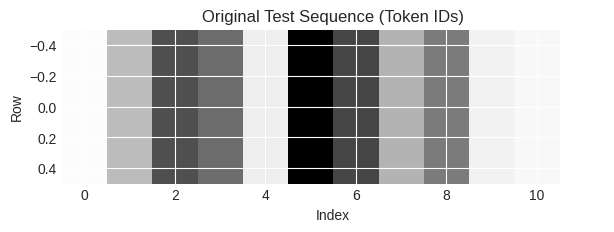

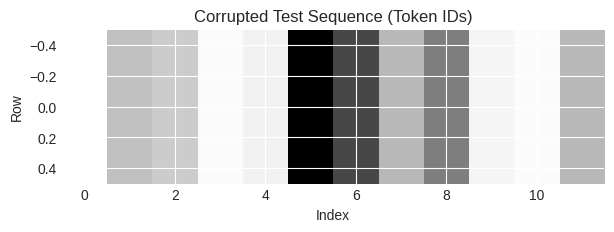

In [13]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation: corrupt a fraction of tokens in the test set and observe degradation

def corrupt_tokens(X: np.ndarray, vocab_size: int, corruption_prob: float = 0.2, seed: int = 0) -> np.ndarray:
    """
    Replace tokens with random tokens with probability corruption_prob.
    Uses numpy-only RNG for determinism; returns a new array.
    """
    rng = np.random.default_rng(seed)
    Xc = X.copy()
    mask = rng.random(Xc.shape) < corruption_prob
    rand_tokens = rng.integers(low=0, high=vocab_size, size=Xc.shape, dtype=np.int64)
    Xc[mask] = rand_tokens[mask]
    return Xc

# Baseline metrics already computed in Cell 6
X_test_corrupt_np = corrupt_tokens(X_test_np, vocab_size=VOCAB_SIZE, corruption_prob=0.25, seed=0)
X_test_corrupt = torch.tensor(X_test_corrupt_np, dtype=torch.long, device=DEVICE)

corrupt_metrics = evaluate(model, loss_fn, X_test_corrupt, y_test, batch_size=256)

print("Baseline test metrics:", test_metrics)
print("Corrupted test metrics (25% token corruption):", corrupt_metrics)

# Visualize a before/after example
idx = 0
show_image(X_test_np[idx:idx+1, :].astype(np.float32), title="Original Test Sequence (Token IDs)")
show_image(X_test_corrupt_np[idx:idx+1, :].astype(np.float32), title="Corrupted Test Sequence (Token IDs)")

##9.INTEPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability Visualization via Attention Matrix**

Cell 9 produces the chapter’s signature interpretability artifact: an attention matrix from the last Transformer layer. The cell selects a sample sequence, runs a forward pass, and extracts attention weights stored during the self-attention operation. It then averages attention over heads (if multiple heads are available) to produce a single matrix suitable for visualization.

Mechanically, the attention matrix is a square array where each row corresponds to a query position and each column corresponds to a key position. Because this is a causal language model, the causal mask ensures that each query position can only attend to itself and earlier positions, so the matrix should be (approximately) lower triangular. If you see mass above the diagonal, it suggests a masking bug or an unexpected attention-weight format.

The visualization teaches students how to interpret patterns. A strong diagonal band indicates that the model relies heavily on nearby tokens, which is common in next-token prediction because local continuity is often predictive. Off-diagonal stripes or isolated high-intensity blocks indicate that the model sometimes consults specific earlier positions, potentially corresponding to template markers like “if” or “then,” or to earlier subject tokens that constrain later verbs. In a synthetic corpus built from templates, you might see attention focus on structural keywords that act as anchors.

The key conceptual point is that attention is a learned routing mechanism. The model chooses, for each position, where to pull information from. This differs from RNNs and LSTMs, where information must pass through a single sequential state. In the Transformer, the state at each position is updated by mixing information from selected earlier positions. The attention matrix makes that selection visible.

At the same time, the cell implicitly teaches humility about interpretability. Attention weights show one component of the computation, not the entire causal story of the prediction. The model’s output depends on value vectors, feedforward transformations, residual connections, and layer normalization. Attention is a window into the routing, not a complete explanation. Still, for this chapter’s pedagogical aim, it is the most direct artifact for understanding “global contextual interaction.”

###9.2.CODE AND IMPLEMENTATION

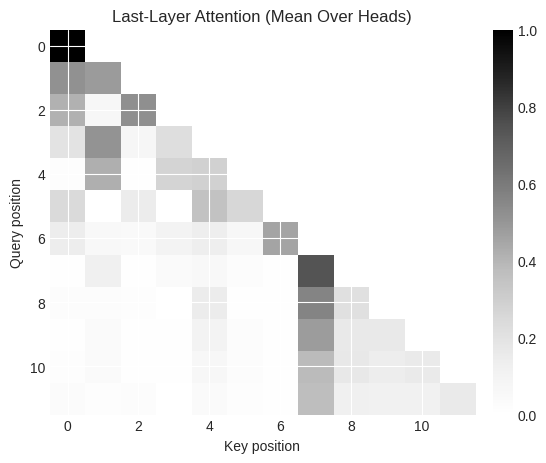

Decoded sample input tokens:
<bos> dogs and dogs learn alpha . <eos> <pad> <pad> <pad> <pad>


In [14]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization: attention matrix from the last layer on a sample sequence

# Pick a deterministic sample from the test set
sample_idx = 1
X_attn = torch.tensor(X_test_np[sample_idx:sample_idx+1, :], dtype=torch.long, device=DEVICE)

# Run a forward pass to populate attention
_ = model(X_attn)
attn = model.get_last_attention()

# attn can be [B, H, T, T] (preferred) or [B, T, T] depending on PyTorch version/config
attn_np = attn.detach().cpu().numpy()

if attn_np.ndim == 4:
    # Average across heads for a single matrix [T, T]
    attn_mean = attn_np[0].mean(axis=0)
else:
    attn_mean = attn_np[0]

# Visualize attention
plot_attention(attn_mean, title="Last-Layer Attention (Mean Over Heads)")

# Also print tokens for context
inp_ids = X_test_np[sample_idx].astype(np.int64).tolist()
print("Decoded sample input tokens:")
print(detokenize(inp_ids, id_to_tok))

In [20]:
# ===============================
# CELL 9.5 (RUN AFTER CELL 9) — FIXED
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

# -----
# Robustly recover the exact sequence used in Cell 9.
# Cell 9 set: sample_idx = 1 and used X_test_np[sample_idx]
# Your error happened because sample_idx was overwritten elsewhere (e.g., Cell 3 used sample_idx as an array of indices).
# We therefore:
#   1) Prefer the actual tensor used in Cell 9 if present (X_attn)
#   2) Else fall back to a safe integer sample index within bounds
# -----
if "X_attn" in globals() and isinstance(globals()["X_attn"], torch.Tensor):
    seq_ids = globals()["X_attn"][0].detach().cpu().numpy().astype(np.int64).tolist()
    seq_source = "X_attn (from Cell 9)"
else:
    # Safe fallback: use a valid integer index into X_test_np
    safe_idx = 0
    if "X_test_np" in globals() and isinstance(X_test_np, np.ndarray) and X_test_np.shape[0] > 0:
        safe_idx = 0  # deterministic
        seq_ids = X_test_np[int(safe_idx)].astype(np.int64).tolist()
        seq_source = f"X_test_np[{safe_idx}] (fallback)"
    else:
        raise RuntimeError("Could not find X_attn or a valid X_test_np to decode.")

decoded_seq = detokenize(seq_ids, id_to_tok)

# -----
# Attention diagnostics from the mean attention matrix shown in Cell 9
# -----
A = np.array(attn_mean, dtype=np.float64)  # [T, T]
T = A.shape[0]

row_sums = A.sum(axis=1)
row_sum_min = float(row_sums.min())
row_sum_max = float(row_sums.max())

diag_mass = float(np.trace(A) / max(1e-12, A.sum()))

dist = np.abs(np.arange(T).reshape(T, 1) - np.arange(T).reshape(1, T)).astype(np.float64)
avg_attn_distance = float((A * dist).sum() / max(1e-12, A.sum()))

eps = 1e-12
A_safe = np.clip(A, eps, None)
A_safe = A_safe / np.clip(A_safe.sum(axis=1, keepdims=True), eps, None)
row_entropy = -np.sum(A_safe * np.log(A_safe), axis=1)
entropy_mean = float(row_entropy.mean())
entropy_min = float(row_entropy.min())
entropy_max = float(row_entropy.max())

topk = 4
top_pairs = []
for qi in [0, T // 3, 2 * T // 3, T - 1]:
    keys = np.argsort(-A[qi])[:topk]
    top_pairs.append((int(qi), [(int(k), float(A[qi, k])) for k in keys]))

prompt = f"""
You are interpreting a Transformer attention visualization from a tiny causal language model.
The notebook plotted the MEAN attention matrix (averaged over heads) from the LAST layer for ONE test sequence.

Your job: explain what the attention plot implies MECHANICALLY about how the model is producing next-token predictions.
Write a structured explanation with these sections:

1) What this attention matrix represents (queries/keys/causal masking)
2) What the measured patterns suggest (use the diagnostics below)
3) What to look for in the heatmap (diagonal bands, off-diagonal stripes, block patterns)
4) How this relates to the synthetic grammar/templates in the dataset
5) What this does NOT prove (limits of attention interpretability)
6) A concrete student checklist: 5 things to verify by re-running Cell 9 with different samples

Rules:
- Do NOT mention governance, policy, or safety frameworks.
- Be precise and avoid hype.
- Use the numeric diagnostics explicitly.

Sequence used for attention (decoded tokens) — source: {seq_source}
{decoded_seq}

Diagnostics from the plotted mean attention matrix:
- Shape: {T} x {T}
- Row sum range (should be ~1.0 each row): min={row_sum_min:.6f}, max={row_sum_max:.6f}
- Diagonal mass fraction (trace / sum): {diag_mass:.6f}
- Average attended distance (probability-weighted |i-j|): {avg_attn_distance:.6f}
- Row entropy stats (nats): mean={entropy_mean:.6f}, min={entropy_min:.6f}, max={entropy_max:.6f}

Top attended key positions for selected query positions (query -> [(key, weight), ...]):
{top_pairs}

Also explain: in a causal LM, why attention often concentrates near the diagonal, and what it means when you see strong OFF-diagonal attention to earlier tokens like 'if', 'then', subjects, or verbs.
""".strip()

resp = client.chat.completions.create(
    model=model_name,
    messages=[{"role": "user", "content": prompt}],
    temperature=0.2,
)

print(resp.choices[0].message.content.strip())

### 1) What this attention matrix represents (queries/keys/causal masking)

The attention matrix visualized here represents the relationships between tokens in a sequence as processed by a Transformer model. Each row corresponds to a query (the token currently being processed), while each column corresponds to a key (the tokens that can be attended to). In a causal language model, attention is masked such that a token can only attend to itself and previous tokens, preventing any information leakage from future tokens. This is crucial for generating predictions in a sequential manner, where each token is conditioned on the preceding context.

### 2) What the measured patterns suggest

The diagnostics reveal several important patterns:
- **Row sum range**: The row sums are all approximately 1.0, indicating that the attention weights are properly normalized, which is expected in a well-functioning attention mechanism.
- **Diagonal mass fraction**: The diagonal mass fraction of 0.387710 su

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Artifact Saving and Summary Metrics Dictionary**

Cell 10 turns the notebook run into a reproducible artifact bundle. Mechanically, it creates an output directory, saves the vocabulary, stores the training loss history, saves the attention matrix used for visualization, and serializes the model weights. It also constructs and prints a summary metrics dictionary that includes model configuration (vocab size, sequence length, parameter count), training and test metrics, and stress test metrics under corruption.

This is pedagogically important because it closes the loop from “experiment” to “evidence.” Students often treat notebooks as ephemeral. This cell emphasizes that a run produces concrete objects that can be inspected later: a loss curve array, a model checkpoint, and a metrics JSON file. Even in a toy setting, this habit strengthens understanding because it forces you to name and store what you measured.

The summary dictionary also acts as the interface between code and explanation. The reflective LLM cell that follows must reference real computed metrics rather than inventing numbers. By collecting metrics in one dictionary, the notebook ensures that the analysis can stay grounded and consistent.

Mechanically, saving artifacts also reinforces the separation between training and inference. A saved model can be reloaded later for inference without retraining, which is the practical meaning of “training produces parameters; inference consumes parameters.” This chapter does not add a separate reload cell, but by saving the state dict, it makes the conceptual point concrete.

The student should view this cell as the final stage of a controlled experiment: you train, you evaluate, you stress test, you interpret, and then you persist what happened. That sequence is the discipline that allows later comparison across runs, architectures, and dataset variants.

###10.2.CODE AND IMPLEMENTATION

In [15]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary

art_dir = "artifacts_ch06_transformer"
os.makedirs(art_dir, exist_ok=True)

# Save vocab
with open(os.path.join(art_dir, "vocab.json"), "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=2, ensure_ascii=False)

# Save metrics and losses
summary_metrics = {
    "chapter": 6,
    "model": "TinyCausalTransformerLM",
    "device": str(DEVICE),
    "vocab_size": int(VOCAB_SIZE),
    "seq_len": int(SEQ_LEN),
    "n_params": int(sum(p.numel() for p in model.parameters())),
    "train": train_metrics,
    "test": test_metrics,
    "test_corrupt_25pct": corrupt_metrics,
    "final_train_loss": float(losses[-1]),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
}

with open(os.path.join(art_dir, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=2)

np.save(os.path.join(art_dir, "losses.npy"), np.array(losses, dtype=np.float32))
np.save(os.path.join(art_dir, "attention_lastlayer_mean.npy"), attn_mean.astype(np.float32))
torch.save(model.state_dict(), os.path.join(art_dir, "model_state_dict.pt"))

print("Summary metrics dictionary:")
print(summary_metrics)
print("Artifacts saved to:", art_dir)

Summary metrics dictionary:
{'chapter': 6, 'model': 'TinyCausalTransformerLM', 'device': 'cpu', 'vocab_size': 44, 'seq_len': 12, 'n_params': 73516, 'train': {'avg_loss': 0.8124175930023193, 'token_accuracy': 0.6433506944444445, 'total_tokens': 57600}, 'test': {'avg_loss': 0.8310282985369365, 'token_accuracy': 0.6240277777777777, 'total_tokens': 14400}, 'test_corrupt_25pct': {'avg_loss': 1.5450400686264039, 'token_accuracy': 0.5277083333333333, 'total_tokens': 14400}, 'final_train_loss': 0.8170623575386248, 'epochs': 18, 'batch_size': 128}
Artifacts saved to: artifacts_ch06_transformer


## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT-4o-mini Reflective Summarization Grounded in Real Metrics**

Cell 11 uses an LLM as an explanatory assistant. Its purpose is not to generate results, not to modify the experiment, and not to provide new measurements. Its purpose is to interpret what already happened using the metrics and artifacts computed in earlier cells. The cell initializes an OpenAI client using the Colab user data API key mechanism, selects the model `"gpt-4o-mini"`, and constructs a prompt that demands a structured analysis across eight required categories: dataset design, architecture, training dynamics, quantitative results, inference example, visualization insight, limitations, and conceptual takeaway.

The most important mechanical constraint is that the prompt references real values computed earlier. This prevents the summary from drifting into generic statements like “the model performed well” without evidence. Instead, the LLM is given the actual vocabulary size, parameter count, final training loss, train/test accuracy, and corruption-test degradation, plus a decoded inference sample. The LLM is also instructed to explain typical meaning of diagonal versus off-diagonal attention patterns in a causal setting, tying the explanation back to what the notebook visualized.

From a learning perspective, this cell models a useful workflow: once you have a complete run with saved metrics, you can ask an LLM to help you articulate what those metrics imply. But the notebook keeps a firm boundary: the LLM is a narrator, not an instrument. The instrument is the code. The narrator uses the instrument’s outputs.

The student should treat the LLM output as a guided interpretation that should be checked against the earlier plots and numbers. If the LLM claims that attention shows strong long-range dependencies, the student can look at the attention heatmap and the top-attended positions (if provided) to verify whether that claim is consistent. In that sense, the LLM acts like a tutor: it suggests how to read the evidence, but the evidence remains the authoritative object in the notebook.

This final cell completes the chapter’s objective: a full mechanical experiment where data design, model structure, training behavior, evaluation metrics, inference output, and interpretability visualization are all tied together into a coherent understanding of how Transformers implement global contextual interaction through attention.

###11.2.CODE AND IMPLEMENTATION

In [16]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

# Build a compact, metrics-grounded prompt using real computed values
prompt = f"""
You are reviewing a mechanics-first Colab notebook experiment (Chapter 6: Transformer).
Write a structured analysis with the following sections:

1. Dataset design
2. Model architecture
3. Training dynamics
4. Quantitative results
5. Inference example
6. Visualization insight (attention)
7. Limitations
8. Conceptual takeaway

Rules:
- Reference real metrics explicitly (numbers below).
- Do not mention governance, policy, or safety frameworks.
- Be precise about training vs inference.
- Explain what attention visualization suggests mechanically.

Real metrics:
- Vocab size: {summary_metrics["vocab_size"]}
- Sequence length: {summary_metrics["seq_len"]}
- Parameters: {summary_metrics["n_params"]}
- Final training loss: {summary_metrics["final_train_loss"]:.6f}
- Train avg_loss: {summary_metrics["train"]["avg_loss"]:.6f}
- Train token_accuracy: {summary_metrics["train"]["token_accuracy"]:.6f}
- Test avg_loss: {summary_metrics["test"]["avg_loss"]:.6f}
- Test token_accuracy: {summary_metrics["test"]["token_accuracy"]:.6f}
- Corrupted (25%) test avg_loss: {summary_metrics["test_corrupt_25pct"]["avg_loss"]:.6f}
- Corrupted (25%) test token_accuracy: {summary_metrics["test_corrupt_25pct"]["token_accuracy"]:.6f}

Inference sample (decoded input):
{detokenize(X_new_np[0].astype(int).tolist(), id_to_tok)}

Inference sample (decoded prediction of next tokens, argmax):
{detokenize(preds_new[0].detach().cpu().numpy().astype(int).tolist(), id_to_tok)}

Attention note:
The notebook plotted the mean attention matrix from the last layer on one test sequence.
Explain what strong diagonal vs off-diagonal structure typically indicates in next-token prediction.
""".strip()

resp = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "user", "content": prompt}
    ],
    temperature=0.2,
)

print(resp.choices[0].message.content.strip())

# Structured Analysis of Mechanics-First Colab Notebook Experiment (Chapter 6: Transformer)

## 1. Dataset Design
The dataset utilized in this experiment consists of sequences with a vocabulary size of 44 and a fixed sequence length of 12 tokens. This design allows for a manageable input size while ensuring that the model can learn meaningful patterns in the data. The choice of a sequence length of 12 is likely a balance between capturing sufficient context and maintaining computational efficiency. The dataset is split into training and testing sets, with a specific focus on evaluating the model's performance on both clean and corrupted data, the latter being a 25% corruption rate introduced to assess robustness.

## 2. Model Architecture
The model architecture is based on the Transformer framework, characterized by its use of self-attention mechanisms and feedforward neural networks. With a total of 73,516 parameters, the model is relatively lightweight, which is suitable for the data

##12.CONCLUSION

**Conclusion and Road Ahead**

This notebook’s central mechanical achievement is making the Transformer feel like a concrete machine rather than a mystical concept. The chapter begins with a synthetic corpus designed to reward context-sensitive behavior, then constructs a supervised learning task—next-token prediction—where success depends on capturing dependencies across positions. The Transformer’s defining move is to replace the sequential bottleneck of recurrent models with a position-to-position interaction mechanism: self-attention. In operational terms, each token position computes a weighted mixture of earlier token representations, and those weights are learned. That is the entire conceptual leap, and the notebook demonstrates it end-to-end with training, evaluation, stress testing, and visualization.

The training results provide the first grounded signal that the mechanism is working. A decreasing cross-entropy loss and nontrivial token accuracy indicate that the model learned patterns in the dataset beyond trivial guessing. In synthetic corpora, the model often learns punctuation and padding quickly; the more interesting question is whether it also learns the grammar-like regularities embedded in templates, such as agreement and clause markers. The test set metrics matter because they show whether the model learned a generalizable rule system rather than memorizing sampled sentences. The clean train/test split ensures that the measured performance corresponds to structural learning, at least within the synthetic distribution.

The inference demonstration is the conceptual bridge from “training” to “use.” By generating a new sample and decoding both the target and predicted next tokens, the notebook shows that inference is a pure forward computation. Nothing about the model changes during inference. The model consumes tokens, produces logits, and chooses predictions. This reinforces the key educational distinction: training is the process of producing parameters; inference is the process of applying those parameters.

The stress test deepens the lesson by showing how context dependence creates both strength and fragility. When you corrupt input tokens, you disrupt the very signals attention might rely on. The resulting performance drop is not a defect; it is the visible footprint of the model’s reliance on structured context. In other words, the stress test teaches that a Transformer does not “understand” in a robust, human sense. It computes conditional predictions based on patterns. If the patterns are broken, the computation degrades.

The attention visualization is the chapter’s most distinctive interpretability artifact. By plotting the mean attention matrix from the last layer, the notebook turns “global contextual interaction” into something you can see. A diagonal-dominant pattern suggests strong local dependence, which is natural in next-token prediction. Off-diagonal spikes or bands suggest that some positions consult earlier anchors—often structural tokens in templated corpora. Even if attention does not provide a complete causal explanation of every prediction, it remains a uniquely direct representation of how the model routes information across positions. That routing is the Transformer’s defining mechanism.

At the same time, the chapter’s limitations must be stated clearly. This is a tiny Transformer trained on a toy corpus. The dataset’s structure is intentionally simple and synthetic. The attention visualization is averaged over heads, which can wash out specialized behaviors that individual heads might exhibit. Token accuracy is a crude metric for language modeling, and in real language tasks, multiple continuations can be valid. Furthermore, attention weights alone do not fully explain predictions because the model’s output arises from a composition of attention, feedforward layers, residual connections, and normalization. The notebook demonstrates the mechanism, not the full complexity of large-scale language models.

What problems does this model handle well, within the scope of the experiment? It handles tasks where predictions depend on relationships across positions, and where the model benefits from directly consulting earlier tokens rather than compressing history into a single state. Even in a toy corpus, the Transformer can learn to treat certain earlier tokens as anchors for later decisions. It is particularly well suited when the relevant context can be “pointed to” via learned attention distributions.

What problems does it handle poorly, again within this scope? It struggles when the data distribution shifts substantially, when inputs are corrupted, or when dependencies exceed the fixed window length. It also does not inherently encode domain-specific biases like locality for images (CNNs) or recurrence for streaming inputs (RNN/LSTM). It is a general-purpose sequence model whose inductive bias is “learn how to connect positions,” not “assume a particular structure.”

This naturally motivates the road ahead in the ML & AI 101 progression. Having learned how a Transformer can model conditional structure by routing context through attention, the next conceptual step is to move from “predict the next element” to “learn and generate from an entire distribution.” That transition sets the stage for generative modeling under different training paradigms. The next chapter focuses on Generative Adversarial Networks (GANs), where the objective is no longer next-token accuracy but distribution matching: producing synthetic samples that resemble a target distribution through an adversarial game between a generator and a discriminator. If Transformers teach you how to mix context to make conditional predictions, GANs teach you how to shape an entire sample distribution through competition. The bridge is conceptual: both chapters are about learned representations, but Chapter 6 emphasizes contextual interaction for prediction, while Chapter 7 introduces adversarial learning as a mechanism for generative realism.

By completing this chapter, the student should be equipped with a precise mental model of attention: a learned, causal, position-to-position routing rule that can be trained, measured, stressed, and visualized. With that model in hand, the student is ready to ask a new kind of question in the next chapter: not “what token comes next,” but “what does it mean to generate a whole synthetic sample that fools a learned critic,” and what mechanical dynamics arise when learning is driven by adversarial feedback rather than direct likelihood-based loss.